# Part B: Data Acquisition 

In [2]:
import pandas as pd
import json
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ydata_profiling import ProfileReport

customers = pd.read_csv('data/customers.csv')
customers.head()

,CustomerID,Name,Age,Gender,City,Income,Purchases,Churn
0,C101,Rohan Patel,24.0,Male,Ahmedabad,45000.0,8,No
1,C102,Neha Shah,29.0,Female,Surat,62000.0,15,No
2,C103,Amit Joshi,35.0,Male,Rajkot,78000.0,20,Yes
3,C104,Priya Mehta,27.0,Female,Vadodara,55000.0,11,No
4,C105,Karan Desai,41.0,Male,Ahmedabad,98000.0,25,Yes


In [3]:
with open('data/employees.json') as f:
    employee = json.load(f)
employees = pd.DataFrame(employee)
employees.head()

,EmployeeID,Name,Department,Age,Salary,Experience,City
0,E201,Rahul Verma,HR,30.0,48000.0,5,Pune
1,E202,Anjali Nair,IT,26.0,65000.0,3,Bengaluru
2,E203,Vikas Singh,Sales,34.0,72000.0,8,Delhi
3,E204,Pooja Iyer,Finance,29.0,61000.0,4,Chennai
4,E205,Ritesh Gupta,IT,NaN,84000.0,9,Hyderabad


In [4]:
conn = sqlite3.connect('data/store.db')
store = pd.read_sql_query("SELECT * FROM products", conn)
store.head()

,ProductID,ProductName,Category,Price,Stock,Brand
0,P301,Laptop,Electronics,55000,15.0,Dell
1,P302,Mouse,Accessories,700,120.0,Logitech
2,P303,Keyboard,Accessories,1500,75.0,HP
3,P304,Monitor,Electronics,12500,28.0,Samsung
4,P305,Office Chair,Furniture,8500,12.0,GreenSoul


In [5]:
url = "https://randomuser.me/api/"
response = requests.get(url)
df = pd.DataFrame(response.json()['results'])
df.head()

,gender,name,location,email,login,dob,registered,phone,cell,id,picture,nat
0,male,"{'title': 'Mr', 'first': 'Hitesh', 'last': 'Ds...","{'street': {'number': 972, 'name': 'Maharanipe...",hitesh.dsouza@example.com,{'uuid': '74f176b4-64dd-4e13-a673-ece2c2f4e287...,"{'date': '1988-12-14T19:35:03.559Z', 'age': 37}","{'date': '2020-08-24T15:28:30.539Z', 'age': 5}",9192915485,9322529236,"{'name': 'UIDAI', 'value': '883666777434'}",{'large': 'https://randomuser.me/api/portraits...,IN


# Part C: Data Understanding & Cleaning

In [6]:
print(customers.head())
print(customers.info())
print(customers.describe())

  CustomerID         Name   Age  Gender       City   Income  Purchases Churn
0       C101  Rohan Patel  24.0    Male  Ahmedabad  45000.0          8    No
1       C102    Neha Shah  29.0  Female      Surat  62000.0         15    No
2       C103   Amit Joshi  35.0    Male     Rajkot  78000.0         20   Yes
3       C104  Priya Mehta  27.0  Female   Vadodara  55000.0         11    No
4       C105  Karan Desai  41.0    Male  Ahmedabad  98000.0         25   Yes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  11 non-null     object 
 1   Name        11 non-null     object 
 2   Age         10 non-null     float64
 3   Gender      11 non-null     object 
 4   City        11 non-null     object 
 5   Income      10 non-null     float64
 6   Purchases   11 non-null     int64  
 7   Churn       11 non-null     object 
dtypes: float64(2), int64(

In [7]:
print(customers.isna().sum())

CustomerID    0
Name          0
Age           1
Gender        0
City          0
Income        1
Purchases     0
Churn         0
dtype: int64


In [9]:
customers['Age'] = customers['Age'].fillna(customers['Age'].mean())
customers['Income'] = customers['Income'].fillna(customers['Income'].mean())

# Part D: Exploratory Data Analysis

### 1. Univariate Analysis

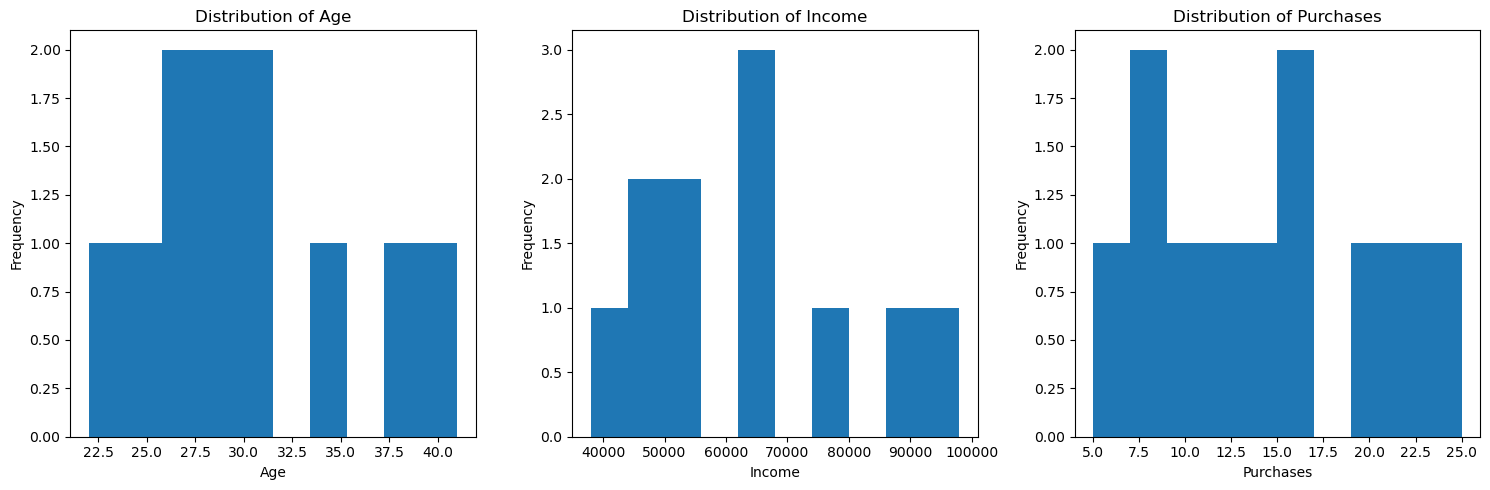

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(customers['Age'])
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(customers['Income'])
axes[1].set_title('Distribution of Income')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Frequency')

axes[2].hist(customers['Purchases'])
axes[2].set_title('Distribution of Purchases')
axes[2].set_xlabel('Purchases')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [19]:
print(customers['Age'].describe())
print(customers['Income'].describe())
print(customers['Purchases'].describe())

count    11.000000
mean     30.200000
std       5.810336
min      22.000000
25%      26.500000
50%      29.000000
75%      33.000000
max      41.000000
Name: Age, dtype: float64
count       11.000000
mean     62300.000000
std      18536.720314
min      38000.000000
25%      49000.000000
50%      62000.000000
75%      70150.000000
max      98000.000000
Name: Income, dtype: float64
count    11.000000
mean     13.636364
std       6.376092
min       5.000000
25%       8.500000
50%      14.000000
75%      17.500000
max      25.000000
Name: Purchases, dtype: float64


In [21]:
print("Skewness:\n")
print(customers['Age'].skew())
print(customers['Income'].skew())
print(customers['Purchases'].skew())
print("\nKurtosis:\n")
print(customers['Age'].kurtosis())
print(customers['Income'].kurtosis())
print(customers['Purchases'].kurtosis())

Skewness:

0.5890385810802804
0.7579302284011218
0.4224842699024639

Kurtosis:

-0.264841778786042
-0.17681857055119155
-0.8073977564502579


### 2. Bivariate Analysis

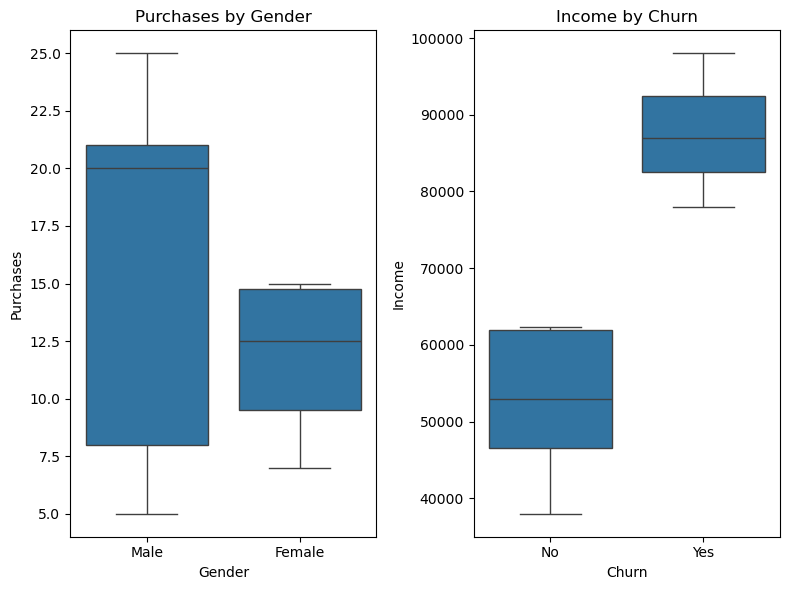

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(8, 6))
sns.boxplot(x='Gender', y='Purchases', data=customers, ax=axes[0])
axes[0].set_title('Purchases by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Purchases')

sns.boxplot(x='Churn', y='Income', data=customers, ax=axes[1])
axes[1].set_title('Income by Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Income')

plt.tight_layout()
plt.show()


### 3. Multivariate Analysis

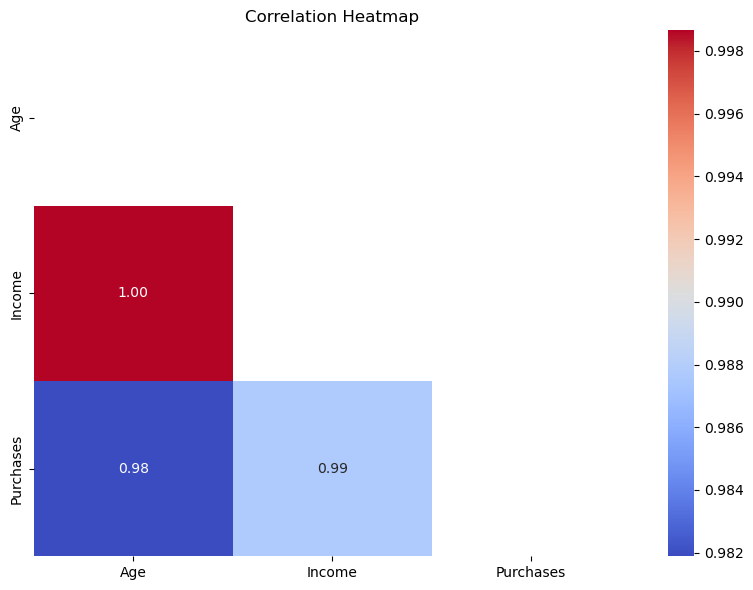


Top Positive Correlations:
Age        Income       0.998658
Income     Age          0.998658
           Purchases    0.987724
Purchases  Income       0.987724
Age        Purchases    0.981884
dtype: float64


In [30]:
# Correlation heatmap of all numerical variables
corr_matrix = customers.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0]
print("\nTop Positive Correlations:")
print(corr_pairs.head(5))

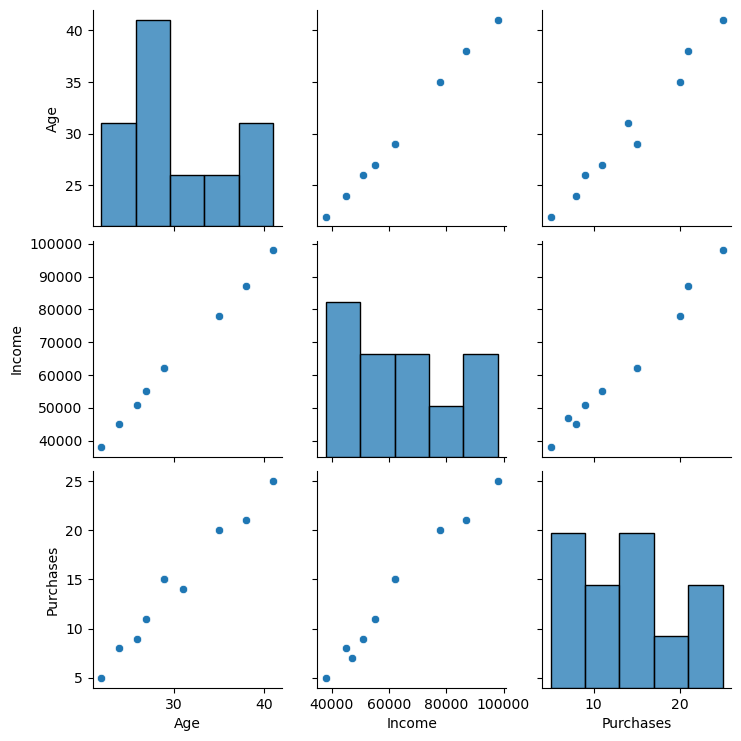

In [31]:
# pairplot to identify feature interactions
sns.pairplot(customers[['Age', 'Income', 'Purchases']])
plt.show()

# Part E: Data Profiling

In [3]:
profile = ProfileReport(
    customers,
    title="Customer Data — Full EDA Report",
    explorative=True      
)

profile.to_file("customer_eda_report.html")
print("Report saved! Browser mein kholo.")

profile.to_notebook_iframe()

profile_minimal = ProfileReport(customers, minimal=True)
profile_minimal.to_file("quick_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 28.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

...

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 128.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]